<b>¡Hola Jean!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!

# Analisis exploratorio 

In [1]:
#importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [1], importaste <code>pandas</code>, <code>matplotlib</code>, <code>numpy</code> y <code>scipy.stats</code>, que son justo las librerías necesarias para este tipo de análisis (EDA, visualización y pruebas estadísticas). Esto ayuda a mantener el notebook ligero y centrado. Buen criterio al no cargar paquetes innecesarios: así el entorno es más claro y reproducible.
</div>

In [2]:
hipotesis = pd.read_csv('/datasets/hypotheses_us.csv',sep=";")
ordenes = pd.read_csv('/datasets/orders_us.csv')
visitas = pd.read_csv('/datasets/visits_us.csv')

In [3]:
# funcion para conocer los df 
def clear_df(df,nombre_df):
    print(nombre_df)
    print(df.info())
    print()
    print(f"En {nombre_df} hay:{df.isna().sum()} datos ausentes")
    print()
    print(f"En {nombre_df} hay: {df.duplicated().sum()} datos duplicados")
    print()
    print(df.head())

In [4]:
clear_df(hipotesis,"Hipotesis")

Hipotesis
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None

En Hipotesis hay:Hypothesis    0
Reach         0
Impact        0
Confidence    0
Effort        0
dtype: int64 datos ausentes

En Hipotesis hay: 0 datos duplicados

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buen uso de <code>.info()</code>, nulos y duplicados en la celda [4] para validar el DataFrame <i>hipotesis</i>. Confirmaste que no hay valores ausentes ni duplicados y que los tipos son correctos. Ese control temprano evita errores silenciosos en los cálculos de ICE/RICE que vienen después.
</div>

En el df Hipotesis se puede evidenciar que no hay datos repetidos o duplicados, se puede ver claramente y con facilidad, son 9 datos. 
lo importante de esto es que todos los datos estan en el tipo de dato necesario para manejarlo eficientemente.

In [5]:
clear_df(ordenes,"Ordenes")

Ordenes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None

En Ordenes hay:transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64 datos ausentes

En Ordenes hay: 0 datos duplicados

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     

Se evidencia que el df no tiene datos usentes y tampoco tiene datos duplicados. Sin embargo, hay un tipo de dato que esta mal. 

In [6]:
ordenes['date'] = pd.to_datetime(ordenes['date'])

In [7]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En las celdas [6]-[7], convertir <code>ordenes['date']</code> a tipo datetime es un paso clave. Esto permite ordenar, agrupar y calcular métricas acumuladas por fecha sin errores de texto. Bien hecho al validar con <code>.info()</code> que el cambio se aplicó correctamente.
</div>

In [8]:
clear_df(visitas,"Vsisitas")

Vsisitas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None

En Vsisitas hay:date      0
group     0
visits    0
dtype: int64 datos ausentes

En Vsisitas hay: 0 datos duplicados

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756


En visias tambien hay un tipo de dato erroneo, es el de la columna 'date'

In [9]:

visitas['date'] = pd.to_datetime(visitas['date'])

In [10]:
visitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


# Analisis de los DataFrame

# Parte 1. Priorizar Hipotesis 

In [11]:
for file in hipotesis['Hypothesis']:
    print(file)

Add two new channels for attracting traffic. This will bring 30% more users
Launch your own delivery service. This will shorten delivery time
Add product recommendation blocks to the store's site. This will increase conversion and average purchase size
Change the category structure. This will increase conversion since users will find the products they want more quickly
Change the background color on the main page. This will increase user engagement
Add a customer review page. This will increase the number of orders
Show banners with current offers and sales on the main page. This will boost conversion
Add a subscription form to all the main pages. This will help you compile a mailing list
Launch a promotion that gives users discounts on their birthdays


In [12]:
# Framework ICE 
# ICE = impact* confidence*ease
# ICE = (inpact*confidence)/effort
hipotesis['ice'] = (hipotesis['Impact']*hipotesis['Confidence'])/hipotesis['Effort']
hipotesis.sort_values('ice',ascending=False).head()


,Hypothesis,Reach,Impact,Confidence,Effort,ice
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000


In [13]:
#Framework RICE
# RICE = (reach*impact*confidence)/effort
hipotesis['rice'] = (hipotesis['Reach']*hipotesis['Impact']*hipotesis['Confidence'])/hipotesis['Effort']
hipotesis.sort_values('rice',ascending=False).head(9)

,Hypothesis,Reach,Impact,Confidence,Effort,ice,rice
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El uso de RICE en la celda [13] está bien aplicado: <code>(Reach * Impact * Confidence) / Effort</code>. Además, mostrar el ranking completo permite comparar cómo cambian las prioridades respecto a ICE. Ese contraste (por ejemplo, la hipótesis del formulario de suscripción sube con RICE por su alto <i>Reach</i>) es una lectura acertada y práctica para la toma de decisiones.
</div>

# Parte 2. Análisis del test A/B

In [14]:
experimento_visitas_order = ordenes.groupby('visitorId')['group'].unique().reset_index()
experimento_visitas_order.head()
 

,visitorId,group
0,5114589,[B]
1,6958315,[B]
2,8300375,"[B, A]"
3,11685486,[A]
4,39475350,[B]


## ¿Cuantos usuarios estan en mas de un experimento?

In [15]:
experimento_visitas_order_ = ordenes.groupby('visitorId')['group'].nunique().reset_index()
experimento_visitas_order_
duplicates_1 = experimento_visitas_order_[experimento_visitas_order_['group']==2]
duplicates_1.count()

visitorId    58
group        58
dtype: int64

In [16]:
repes = 0
id_repe = []
for index, row in experimento_visitas_order.iterrows():
    if len(row['group']) > 1:
        repes+=1
        id_repe.append(row['visitorId'])
print(repes)

58


In [17]:
print(f"En el experimento hay {repes} usuarios repetidos")
print(f"En el experimento el porcentaje de repetidos es: {repes/len(experimento_visitas_order)*100}%")

En el experimento hay 58 usuarios repetidos
En el experimento el porcentaje de repetidos es: 5.625606207565471%


In [18]:
orders_clean_repes = ordenes[~ordenes['group'].isin(id_repe)]

In [19]:
orders_clean_repes.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


## Ingreso acumulado por grupo

In [20]:
# combinaciones de fecha y grupo
dategroup = orders_clean_repes[['date','group']].drop_duplicates()

In [21]:
#  obtener datos diarios acumulados de ordenes
orderagregate = dategroup.apply(lambda x:orders_clean_repes[
    np.logical_and(orders_clean_repes['date'] <= x['date'],
                   orders_clean_repes['group']==x['group'])].agg(
        {'date':'max',
         'group':'max',
         'visitorId':pd.Series.nunique,
         'transactionId':pd.Series.nunique,
         'revenue':'sum'
        }),axis=1).sort_values(['date','group'])

orderagregate.head(2)

,date,group,visitorId,transactionId,revenue
55,2019-08-01,A,20,24,2356.8
66,2019-08-01,B,20,21,1620.0


In [22]:
# obtener datos diarios acumulados de visitas
visitagregate = dategroup.apply(lambda x: visitas[
    np.logical_and(visitas['date']<=x['date'],
                   visitas['group']==x['group'])].agg(
        {'date':'max',
         'group':'max',
         'visits':'sum'}),axis=1).sort_values(['date','group'])
visitagregate.head(2)

,date,group,visits
55,2019-08-01,A,719
66,2019-08-01,B,713


In [23]:
# combinarlos dos df (orderagregate y visitagregate)
combin_order_visit = orderagregate.merge(visitagregate, on=['date','group'])
combin_order_visit.columns = ['date','group','visitors', 'transactions', 'revenue', 'visits']

In [24]:
cumulative_groupA = combin_order_visit[combin_order_visit['group']=='A'][['date','visitors', 'transactions', 'revenue', 'visits']]

In [25]:
cumulative_groupB = combin_order_visit[combin_order_visit['group']=='B'][['date','visitors', 'transactions', 'revenue', 'visits']]

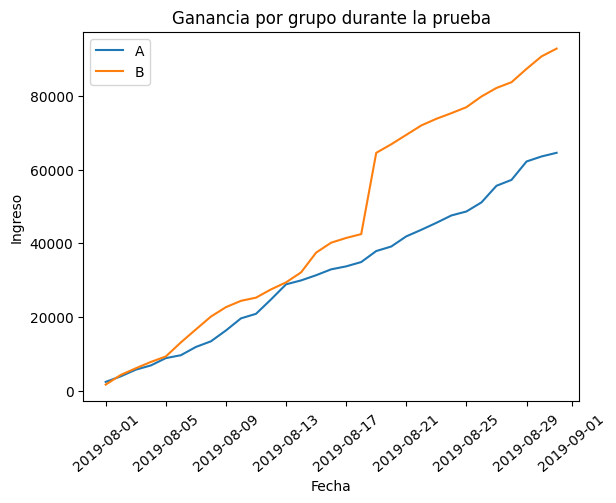

In [26]:
plt.plot(cumulative_groupA['date'],cumulative_groupA['revenue'],label='A')
plt.plot(cumulative_groupB['date'],cumulative_groupB['revenue'],label='B')
plt.xticks(rotation= 40)
plt.xlabel("Fecha")
plt.ylabel("Ingreso")
plt.title("Ganancia por grupo durante la prueba")
plt.legend()
plt.show()

Se denota que a lo largo de la prueba se generaron mas ingresos por parte de los del grupo B. Las cuales tuvieron un salto despues de la fecha: 2019-08-17 y continuo con uncrecimiento parecido al que venia teniendo. 

## Tamaño de pedido promedio acumulado por grupo

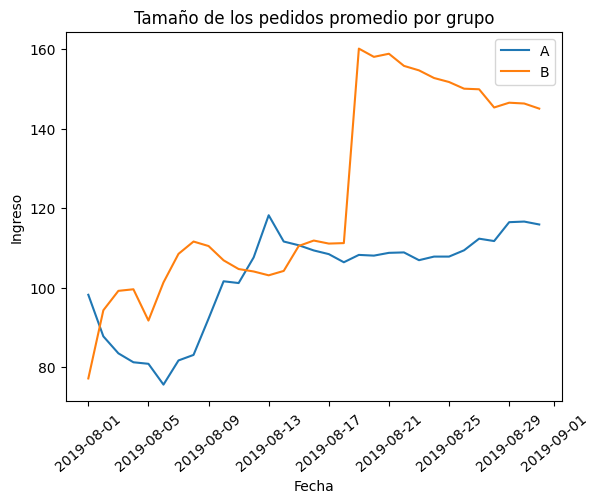

In [27]:
# tamaño promedio de compra por grupo
plt.plot(cumulative_groupA['date'],cumulative_groupA['revenue']/cumulative_groupA['transactions'],label='A')
plt.plot(cumulative_groupB['date'],cumulative_groupB['revenue']/cumulative_groupB['transactions'],label='B')
plt.xticks(rotation=40)
plt.xlabel("Fecha")
plt.title("Tamaño de los pedidos promedio por grupo")
plt.ylabel("Ingreso")
plt.legend()
plt.show()

En un comienzo el grupo B tuvo un par de cresctas, al grupo A, cerca a la decha del 13 de agosto de 2019 tuvo un mayor promedio de pedidos; posteriormente, hay un salto el grupo B hasta 160 y despues se ve un desenso para quedar cerca de 140

## Diferencia relativa en el tamaño de pedido

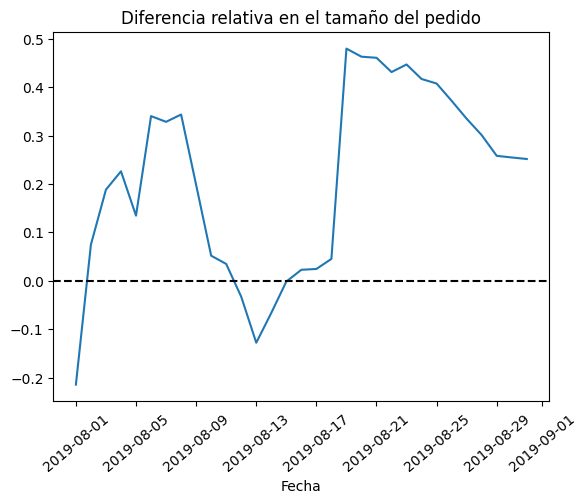

In [28]:
# Grafico de diferencia relativa
## Volviendo a unir los df de los grupos A y B
### df[B]/df[A]
merged_cumulative_groups = cumulative_groupA.merge(cumulative_groupB, on=['date'], suffixes=['A','B'])
plt.plot(merged_cumulative_groups['date'],
         (merged_cumulative_groups['revenueB']/merged_cumulative_groups['transactionsB'])/
        (merged_cumulative_groups['revenueA']/merged_cumulative_groups['transactionsA'])-1)
plt.axhline(y=0, color='black',linestyle='--')
plt.title("Diferencia relativa en el tamaño del pedido")
plt.xlabel("Fecha")
plt.xticks(rotation=40)
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [28], calcular la diferencia relativa del ticket medio de B respecto a A y trazarla con una línea base en 0 es una excelente decisión. Esta vista facilita ver en qué momentos B supera a A y por cuánto. Es una visualización directa que acompaña muy bien el análisis estadístico posterior.
</div>

La mayor parte del area de la grafica se encuentra sobre cero, lo cual indica que el grupo B tiene un mayor tamaño de pedido. O sea, el cambio si ha favorecido a que haya mas compras.

## Tasa de conversion acumulada

In [29]:
# conversion acumulada
combin_order_visit['convertion'] = combin_order_visit['transactions']/combin_order_visit['visits']

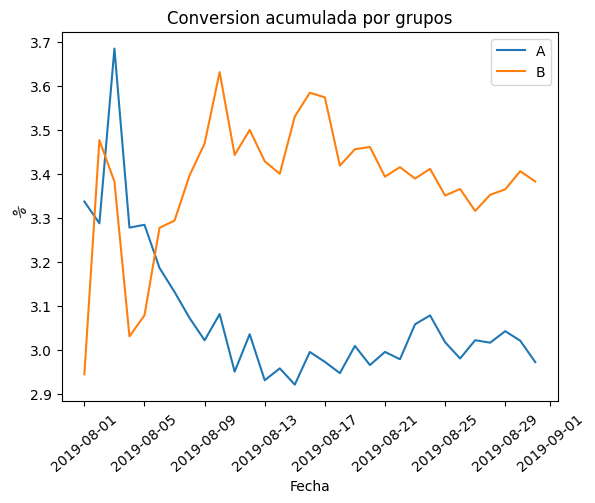

In [30]:
# conversion acumulada
cumulative_groupA_1 = combin_order_visit[combin_order_visit['group']=='A']
cumulative_groupB_1 = combin_order_visit[combin_order_visit['group']=='B']
plt.plot(cumulative_groupA_1['date'], cumulative_groupA_1['convertion']*100, label='A')
plt.plot(cumulative_groupB_1['date'], cumulative_groupB_1['convertion']*100, label='B')
plt.xticks(rotation=40)
plt.xlabel("Fecha")
plt.title("Conversion acumulada por grupos")
plt.ylabel("%",rotation=45)
plt.legend()
plt.show()

Igual que en cualquier prueba, los comienzos tienen a ser volatiles, pero con el tiempo los datos se van estabilizando. Aqui se nota con facilidad que el grupo B tuvo mayor conversion que el grupo A.

Hasta este punto se puede afirmar que las pruebas A/B han sido satisfactorias, pues los cambios enel grupo B han logrado una mayor conversion y un mayor tamaño de compra. Sin embargo, nonos podemos fiar del todo, pues, puede que el crecimiento del grupo B no sea por los cambios implementados sino por variables no contempladas.

Aun hay ue hacer un estudio de los datos anomalos y ver si al quitarlos aun hay una superioridad del grupo B frente al grupo A.

## Dispersión del numero de pedidos por usuario

In [31]:
# grafico dispersión del numero de pedidos por usuario en grupo A
pedidosA= (orders_clean_repes[orders_clean_repes['group']=='A']
          ).groupby('visitorId',as_index=False).agg({'transactionId':pd.Series.nunique})
pedidosA.head(2)

,visitorId,transactionId
0,8300375,1
1,11685486,1


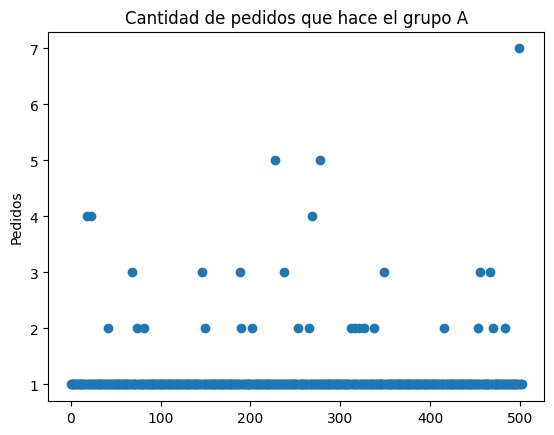

In [32]:
x_values_pedidosA = pd.Series(range(0, len(pedidosA['transactionId'])))
plt.scatter(x_values_pedidosA, pedidosA['transactionId'])
plt.ylabel("Pedidos")
plt.title("Cantidad de pedidos que hace el grupo A")
plt.show()

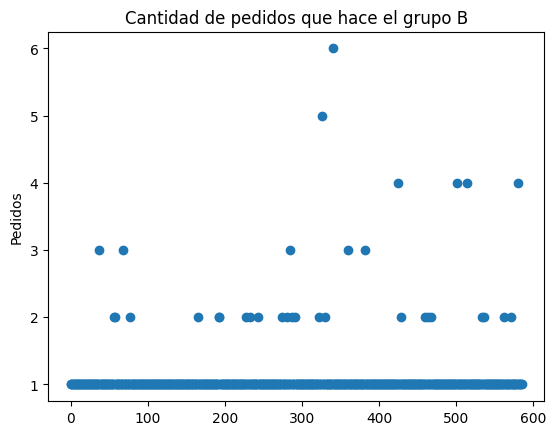

In [33]:
# grafico dispersión del numero de pedidos por usuario en grupo B
pedidosB= (orders_clean_repes[orders_clean_repes['group']=='B']
          ).groupby('visitorId',as_index=False).agg({'transactionId':pd.Series.nunique})

x_values_pedidosB = pd.Series(range(0, len(pedidosB['transactionId'])))
plt.scatter(x_values_pedidosB, pedidosB['transactionId'])
plt.ylabel("Pedidos")
plt.title("Cantidad de pedidos que hace el grupo B")
plt.show()

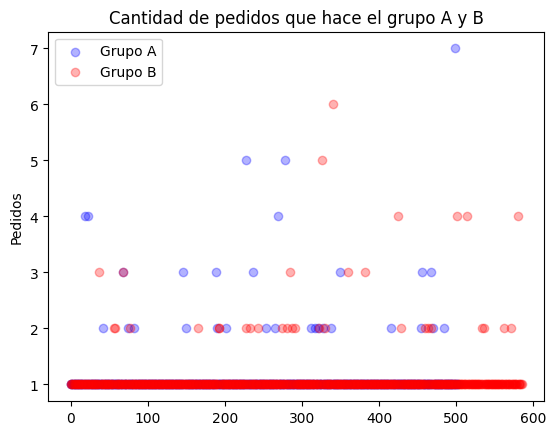

In [34]:
plt.scatter(x_values_pedidosA, pedidosA['transactionId'],color='blue',alpha=0.3, label='Grupo A')
plt.scatter(x_values_pedidosB, pedidosB['transactionId'],color='red',alpha=0.3, label='Grupo B' )
plt.legend()
plt.ylabel("Pedidos")
plt.title("Cantidad de pedidos que hace el grupo A y B")
plt.show()

Tantos los del grupo A como los del grupo B, en su mayoria, realizan un solo pedido.
Tambien hay 2, 3 y hasta 4 pedidos por diversas personas, tabien hay cientes quepidieron 5 vece y uno que pidio hasta 7 veces, claramente estos ultumos son una anomalia. Es momento de ver en que momento se vuelven una anomalia. 

## Percentiles 95 y 99 del numero de pedidos por usuario

In [35]:
# calculo de percentiles
#punto en el cual se convierte en anomalia
print(np.percentile(pedidosA['transactionId'], [95 ,99]))
print(np.percentile(pedidosB['transactionId'], [95 ,99]))

[2.   3.98]
[2.   3.15]


Despues de realizar los percentiles, se evidencia que en los dos grupos, e percentil 95 indica que el 95% de las personas hicieron dos o menos pedidos, por ende, despues de 2 pedidos por usuario se vuelve una anomalia.

## Dispersión de los precios de los pedidos

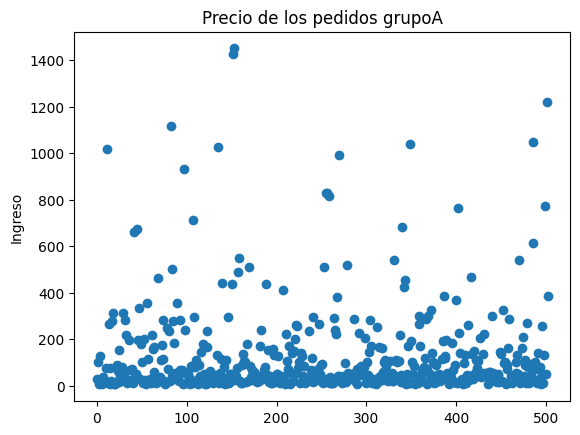

In [36]:
# grafico dispersion precio de los pedidos grupo A
preciosA= (orders_clean_repes[orders_clean_repes['group']=='A']
          ).groupby('visitorId',as_index=False).agg({'revenue':'sum'})

x_values_preciosA = pd.Series(range(0, len(preciosA['revenue'])))
plt.scatter(x_values_preciosA, preciosA['revenue'])
plt.title("Precio de los pedidos grupoA")
plt.ylabel("Ingreso")
plt.show()

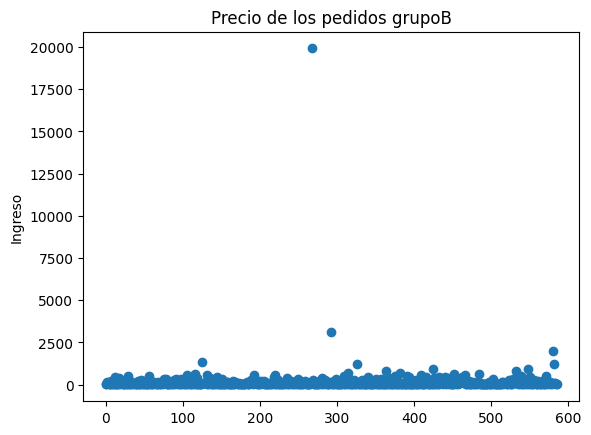

In [37]:
# grafico dispersion precio de los pedidos grupo B
preciosB= (orders_clean_repes[orders_clean_repes['group']=='B']
          ).groupby('visitorId',as_index=False).agg({'revenue':'sum'})

x_values_preciosB = pd.Series(range(0, len(preciosB['revenue'])))
plt.scatter(x_values_preciosB, preciosB['revenue'])
plt.title("Precio de los pedidos grupoB")
plt.ylabel("Ingreso")
plt.show()

En principio se ve gran diferencia entre los dos grupos, pero hay que prestarle atencion a el eje 'Y', mientras que en el grupo A llega a 1400, en el grupo B hay una anomalia de 20000

Realizando un filtrado, para dejar masomenos los mismos limites de los datos, se ve un mayor parecido entre las graficas del grupo A y del grupo B

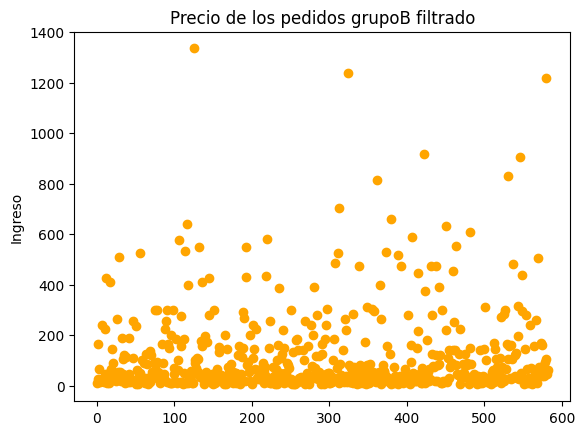

In [38]:
preciosB = preciosB[preciosB['revenue']<1500]

x_values_preciosB = pd.Series(range(0, len(preciosB['revenue'])))
plt.scatter(x_values_preciosB, preciosB['revenue'],color='orange')
plt.title("Precio de los pedidos grupoB filtrado")
plt.ylabel("Ingreso")
plt.show()

Para comparar de la mejor manera, se combinan los dos graficos de dispersión.

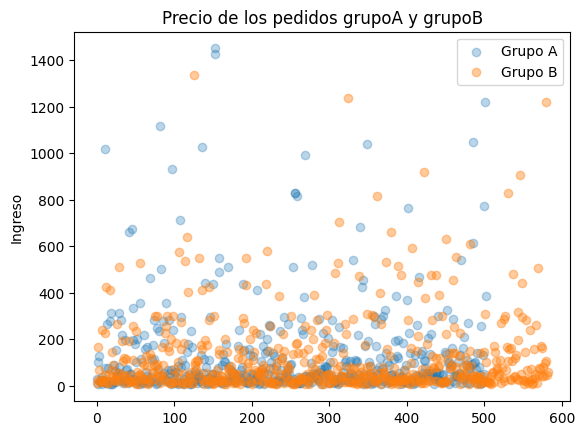

In [39]:
plt.scatter(x_values_preciosA, preciosA['revenue'],alpha=0.3, label='Grupo A')
plt.scatter(x_values_preciosB, preciosB['revenue'],alpha=0.4, label='Grupo B')
plt.title("Precio de los pedidos grupoA y grupoB")
plt.ylabel("Ingreso")
plt.legend()
plt.show()

Visualmente se puede ver que hay mas valores del grupo A sobre 600, pero eso se confirmara mas adelante con metodos menos subjetivos.

## Percentiles 95 y 99 de los precios de los pedidos 

In [40]:
print("Percentiles del grupo A",np.percentile(preciosA['revenue'], [95,99]))
print("Percentiles del grupo B",np.percentile(preciosB['revenue'], [95,99]))

Percentiles del grupo A [ 509.25 1040.5 ]
Percentiles del grupo B [475.21 818.41]


In [41]:
print(np.percentile(preciosA['revenue'], [95])-np.percentile(preciosB['revenue'], [95]))

[34.04]


In [42]:
print(np.percentile(preciosA['revenue'], [99])-np.percentile(preciosB['revenue'], [99]))

[222.09]


El precio de los pedids de grupo A es mayor que los precios del grupo B. Lo cual indica un mayor gasto por parte de los del grupo A. La diferencia entre los percentiles 95 es de 34 y la de los percentiles 99 es de 222.

## Significancia estadistica de la diferencia de conversión entre grupos (datos brutos)

In [43]:
# Significancia estadistica de la diferencia en la conversion entre los grupos 
order_by_uA = orders_clean_repes[orders_clean_repes['group']=='A']. groupby('visitorId',as_index=False).agg({'transactionId':pd.Series.nunique})
order_by_uA.columns = ['visitante', 'orden']
order_by_uB = orders_clean_repes[orders_clean_repes['group']=='B']. groupby('visitorId',as_index=False).agg({'transactionId':pd.Series.nunique})
order_by_uB.columns = ['visitante', 'orden']

In [44]:
sample_A = pd.concat(
    [order_by_uA['orden'],
    pd.Series(0, index=np.arange(
        visitas[visitas['group']=='A']['visits'].sum() - len(order_by_uA['orden'])
    ),name='orders')],axis=0
)

In [45]:
sample_B = pd.concat(
    [order_by_uB['orden'],
    pd.Series(0, index=np.arange(
        visitas[visitas['group']=='B']['visits'].sum() - len(order_by_uB['orden'])
    ),name='orders')],axis=0
)

In [46]:
print(stats.mannwhitneyu(sample_A, sample_B))

MannwhitneyuResult(statistic=176473106.0, pvalue=0.016792355056752608)


In [47]:
print("{0:.4f}".format(stats.mannwhitneyu(sample_A, sample_B)[1]))

0.0168


In [48]:
print("{0:.3f}".format(sample_B.mean()/sample_A.mean()-1))

0.138


El valor P es 0.0168 y es menor que 0.05, lo cual indica que hay que rechazar la hipotesis nula.

Tambien se evidencia que hay un margen de 13,8% de ganancia en el grupo B.

## Significancia estadistica de la diferencia de tamaños promedio de pedido (datos brutos)

In [49]:
stats.mannwhitneyu(orders_clean_repes[orders_clean_repes['group']=='A']['revenue'],orders_clean_repes[orders_clean_repes['group']=='B']['revenue'])

MannwhitneyuResult(statistic=175872.5, pvalue=0.6915246773264736)

In [50]:

print("{0:.3f}".format(stats.mannwhitneyu(orders_clean_repes[orders_clean_repes['group']=='A']['revenue'],orders_clean_repes[orders_clean_repes['group']=='B']['revenue'])[1]))

0.692


In [51]:

print("{0:.3f}".format(stats.mannwhitneyu(orders_clean_repes[orders_clean_repes['group']=='B']['revenue'],orders_clean_repes[orders_clean_repes['group']=='A']['revenue'])[1]))

0.692


El valor p es 0.692 el cual es mucho mayor a 0.05, lo qcual indica que no se puede rechazar la hipotesis nula.

In [52]:

print("{0:.3f}".format(orders_clean_repes[orders_clean_repes['group']=='B']['revenue'].mean()/orders_clean_repes[orders_clean_repes['group']=='A']['revenue'].mean()-1))

0.252


Los datos tambien indican que hay un 25,2% de ganancia

##  Significacion estadistica de la diferencia de conversión entre grupos (datos filtrados)

Con los datos obtenidos anteriormente ya se puede definir los limites del filtro. 

En la cantidad de pedidos, mas de dos pedidos se convierne en anomalia, por ello el limite será 2 pedidos.

En el precio promedio de los pedidos hay dos percentiles diferentes, uno para cada grupo, para tener mejor control de los resultados, se tomara el valor minimo de los percentiles 95 de ambos grupos.

In [53]:
# filtro para usuarios con mas de 2 ordenes
usuarios_masd_2 = pd.concat([order_by_uA[order_by_uA['orden']>3]['visitante'],
                  order_by_uB[order_by_uB['orden']>3]['visitante']],axis=0)

In [54]:
# filtro para clientes con un precio por pedido alto
u_precio_alto = orders_clean_repes[orders_clean_repes['revenue']>(475.21)]['visitorId']

In [55]:
# Unir los dos filtros para obtener los usuarios anomalos
u_anomalos = (pd.concat([usuarios_masd_2,u_precio_alto],axis=0).drop_duplicates().sort_values())

In [56]:
u_anomalos.shape

(57,)

Despues de aplicar el filtro se ve que hay 57 datos anomalos.

In [57]:
orders_clean_repes.shape[0]- u_anomalos.shape[0]

1140

In [58]:
u_anomalos.shape[0]/orders_clean_repes.shape[0]*100

4.761904761904762

Esos 57 datos anomalos representan el 4,7% de los datos limpios de personas que estaban en las dos pruebas.

In [59]:
#  averiguar como esos 57 clientes afectaron a los resultados
sampleAfiltro = pd.concat([
    order_by_uA[np.logical_not(order_by_uA['visitante'].isin(u_anomalos))]['orden'],
    pd.Series(0, index=np.arange(visitas[visitas['group']=='A']['visits'].sum() - len(order_by_uA['orden'])),name='ordenes')],axis=0)


In [60]:
sampleBfiltro = pd.concat([
    order_by_uB[np.logical_not(order_by_uB['visitante'].isin(u_anomalos))]['orden'],
    pd.Series(0, index=np.arange(visitas[visitas['group']=='A']['visits'].sum() - len(order_by_uB['orden'])),name='ordenes')],axis=0)

In [61]:
# Aplicar mannwhitney
print(stats.mannwhitneyu(sampleAfiltro, sampleBfiltro))
print("{0:.4f}".format(stats.mannwhitneyu(sampleAfiltro, sampleBfiltro)[1]))

MannwhitneyuResult(statistic=174105581.0, pvalue=0.011932155852951322)
0.0119


El pvalue es menor que 0.05, se puede rechazar la hipotesis nula.

In [62]:
print("{0:.3f}".format((sampleBfiltro.mean()/sampleAfiltro.mean())-1))

0.159


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Tras el filtrado (celdas [61]-[62]), reportas el nuevo p-valor y el cambio relativo de conversión. Este doble reporte (significancia + tamaño del efecto) es una buena práctica, porque no solo dices si hay diferencia, sino también cuánto cambia. Eso ayuda a una decisión de negocio más informada.
</div>

La diferencia estadistica de la conversión es 15,9% favorable para el grupo B 

## Significancia estadistica de la diferencia en el tamaño promedio por grupo (Datos filtrados)

In [63]:
sig_st_dfilt = stats.mannwhitneyu(
    orders_clean_repes[np.logical_and(
        orders_clean_repes['group']=='A',
        np.logical_not(orders_clean_repes['visitorId'].isin(u_anomalos)))]['revenue'],
    orders_clean_repes[np.logical_and(
        orders_clean_repes['group']=='B',
        np.logical_not(orders_clean_repes['visitorId'].isin(u_anomalos)))]['revenue']
)

In [64]:
sig_st_dfilt 

MannwhitneyuResult(statistic=144167.5, pvalue=0.9932595718968056)

In [65]:
print("{0:.4f}".format(sig_st_dfilt[1]))

0.9933


In [66]:
(orders_clean_repes[np.logical_and(orders_clean_repes['group']=='B',
    np.logical_not(orders_clean_repes['visitorId'].isin(u_anomalos)))]['revenue'].mean()/
orders_clean_repes[np.logical_and(orders_clean_repes['group']=='A',
    np.logical_not(orders_clean_repes['visitorId'].isin(u_anomalos)))]['revenue'].mean()-1)

-0.01945295250214296

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [66], calculas la diferencia relativa de ticket medio tras filtrar outliers, y explicas que el resultado queda levemente desfavorable para B. Es valioso que contrastes los hallazgos brutos versus filtrados y extraigas una conclusión cauta: esto muestra criterio al no depender de una sola vista de los datos.
</div>

 # Decisición 

Antes de conocer la decicion, hagamos un resumen de lo obtenido.
Recopilacion de los datos obtenidos:

Datos brtos:
- Significancia estadistica de la diferencia de conversión entre grupos (Datos brutos): pvalue=0.016792355056752608 y la ganancia relativa es de 0.138
- Significancia estadistica de la diferencia de tamaños promedio de pedido (Datos brutos): pvalue=0.6915246773264736 y  y la diferencia entre los grupos es de 0.252

Datos filtrados: 

- Significacion estadistica de la diferencia de conversión entre grupos (Datos filtrados): pvalue=0.011932155852951322 y   y la ganancia relativa es de 0.159
- Significancia estadistica de la diferencia en el tamaño promedio por grupo (Datos filtrados): pvalue=0.9932595718968056 y y la diferencia entre los grupos es de -0.01945

En los datos brutos el pvalue de la vonversion si es menor a 0,05, lo cual indica que se puede rechazar la hipotesis nula, y la ganancia relativa de la conversion es de un 13,8%, lo cual indica que la prueba es favorable en el grupo B; la significancia estadistica de los tamaños promedio dice cosas opuestas, el pvalue es 0,69, mucho mayor que 0,05, lo cual indica que no se puede rechazar la hipotesis nula, pero la diferencia entre los grupos es de un 25% favorable para el grupo B.

En los datos filtrados la significancia estadistica de la diferencia de conversion tiene un pvalue de 0.011, lo cual es mas pequeño que 0,05, por ende se puede rechazar la hipotesis nula, su ganancia relativa es de 15,9,estos datos confirman la favorabilidad hacia el grupo B; en la significancia estadistica de la diferencia en el tamaño promedio el pvalue es 0,99, lo cual es mucho mas alto que 0,05, y la diferencia entre los grupos es  1,9% desfavorable para el grupo B.

Con respecto a la diferencia de conversión se puede obtener la misma conclusion: en el grupo B hay una mayor conversion con respecto a los del grupo A. 
Con respecto a la diferencia de tamaño promedio hay una gran cambio, en la diferencia de los grupos comienza con una favorabilidad para el grupo B pero al filtrar los datos se vuelve levemente desfavorable.

En conclusion, el grupo B es lider en conversión pero no en el tamaño promedio. El objetivo de la peurba era obtener mayor conversion pero tambien lograr un tamaño promedio mas grande, y despues de realizar las pruebas se evidencia que los cambios realizados no lograron el objetivo. En este momento la mejor opción seria parar la prueba, pues no hay diferencia entre los grupos. Una opción adicional puede ser analizar que fue lo que genero que si haya habido conversion pero que los clientes no hayan aumentado el tamaño promedio de pedidos.


<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Jean! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Cargaste y validaste los datos con <code>.info()</code>, nulos y duplicados de forma sistemática (celdas 4, 5, 8).<br>
• Convertiste correctamente las columnas de fecha a <code>datetime</code>, asegurando análisis temporales fiables (celdas 6–7 y 9–10).<br>
• Definiste y aplicaste ICE y RICE de forma consistente con las columnas disponibles, y comparaste sus rankings (celdas 12–13).<br>
• Identificaste usuarios presentes en ambos grupos y cuantificaste su proporción, mostrando cuidado por la validez del experimento (celdas 14–17).<br>
• Construiste métricas acumuladas de ingresos, visitas y transacciones por grupo, lo que permitió análisis de evolución temporal (celdas 21–25).<br>
• Visualizaste ingresos acumulados y ticket medio con ejes claros y leyendas, facilitando la interpretación (celdas 26–27).<br>
• Mostraste la diferencia relativa del ticket B vs A con línea base, una visualización muy informativa (celda 28).<br>
• Calculaste y analizaste la conversión acumulada por grupo, observando estabilización y diferencias (celda 30).<br>
• Investigaste outliers con percentiles 95/99 para pedidos por usuario y montos, apoyando decisiones de filtrado (celdas 35 y 40).<br>
• Contrastaste resultados “brutos” y “filtrados” en significancia y tamaño del efecto, aportando una visión completa (celdas 43–52 y 61–66).<br>
• Reportaste p-valores y cambios relativos, combinando significancia estadística con relevancia práctica (celdas 47–48 y 62).<br>
• Mantuviste una narrativa clara hasta la decisión final, explicando por qué conviene detener la prueba y qué analizar después (sección de decisión).<br>
• Usaste agregaciones por usuario para construir las muestras de conversión, cuidando la lógica de exposición (celdas 43–45).<br>
• Ilustraste dispersión de pedidos y de ingresos por usuario, ayudando a detectar valores atípicos visualmente (celdas 32–34 y 36–39).<br>
• Al establecer umbrales de outliers, razonaste con percentiles en lugar de cortes arbitrarios, lo que hace el criterio defendible (celdas 35 y 40).<br>
• Integraste métricas acumuladas y puntuales, mostrando el efecto de eventos específicos como el salto de mediados de agosto (celdas 26–28).<br>
• Cuidaste la reproducibilidad al mantener cálculos y visualizaciones paso a paso, lo que permite verificar cada resultado (todo el flujo).<br>
<br>
¡Felicidades!
</div>